# 12-v5 — TCN: Dynamic σ-TBM + Frozen-Backbone WFO

**Option Y — Endogenous Latent Adaptation**: scale-invariant architecture that learns the vol regime from the data itself, then auto-adjusts entry thresholds without hardcoded rules.

| Dimension | v4 | v5 |
|-----------|---------|----------|
| Feature set | ~35 selected (RF+corr) | **All 196 features** (no selection) |
| SEQ_LEN | 24 | **48** |
| Dropout | 0.40 | **0.20** |
| QT fitting | Once on full train_df | **Per-fold** on training rows only |
| TBM barriers | ±2.0×ATR14 | **±2.0×24h rolling σ** (dynamic) |
| Vol target | Forward 6h σ | **Current 24h rolling σ / median** |
| MultiTask loss | weight·CE(none) ✓ | same (fix confirmed) |
| Entry limit price | px − ent_atr×atr ← **BUG** | **px × (1 − ent_atr×atr)** |
| Thresholding | Fixed per config | **Dynamic**: thr_t = base ± vol_scale×vol_pred_t |
| Production inference | Static model | **Frozen-backbone WFO** (heads every 720 h) |

In [1]:
SYMBOL    = 'BTCUSDT'
INTERVAL  = '1h'
TRAIN_END = '2024-06-01'
VAL_END   = '2025-01-01'
TEST_END  = '2026-05-01'

SEQ_LEN       = 48
TCN_CHANNELS  = [64, 64, 64, 64]
TCN_KERNEL    = 3
TCN_DROPOUT   = 0.20
FRAC_D        = 0.40
FFD_THRES     = 1e-4

EPOCHS_FOLD   = 60
PATIENCE_FOLD = 10
EPOCHS_PROD   = 80
PATIENCE_PROD = 15
BATCH_SIZE    = 256
LR            = 3e-4
WEIGHT_DECAY  = 1e-4
WARMUP_EPOCHS = 5
LAMBDA_VOL    = 0.50

K                    = 5
EMBARGO              = 168
KFOLD_INTERNAL_VAL_H = 2500
MIN_TRADES           = 30

# Dynamic TBM barriers from 24h rolling σ of log returns
TBM_VOL_WINDOW = 24
TBM_MULT       = 2.0
TBM_VERT_H     = 24

# Execution / fees (Spot/Futures routing, same as v4)
MAKER_FEE         = 0.0000
SPOT_TAKER_FEE    = 0.0005
FUTURES_TAKER_FEE = 0.0005
BUFFER            = 0.0005
SPOT_FUNDING_H    = 0.0
SHORT_FUNDING_H   = 0.0000077
MIN_SL            = 0.010

OPTIMISE_METRIC = 'sharpe'
TOP_N           = 20

# Frozen-backbone WFO
WFO_STEP_H     = 720    # retrain heads every ~30 days
WFO_LOOKBACK_H = 2160   # trailing 3 months per step
WFO_EPOCHS     = 5
LR_WFO         = 1e-4

# Trading grid  4×3×2×2×2×2×1×1 = 192 combos
TRADING_GRID = {
    'base_threshold':    [0.40, 0.45, 0.50, 0.55],
    'vol_scale':         [0.05, 0.10, 0.20],
    'entry_atr_mult':    [0.20, 0.40],
    'sl_atr_multiplier': [1.50, 2.00],
    'tp_atr_multiplier': [2.00, 3.00],
    'min_hold':          [8, 16],
    'max_hold':          [48],
    'cooldown':          [4],
}

SEED = 42

In [2]:
import copy
import itertools
import json
import math
import pickle
import random
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import QuantileTransformer
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

from hmats.data.splits import calendar_split

warnings.filterwarnings('ignore')
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available() and torch.backends.mps.is_built(): DEVICE = torch.device('mps')
else:                            DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'
RED='#EF5350'; GREEN='#26A69A'; PURPLE='#7B1FA2'

REPO_ROOT    = Path.cwd().parents[2]
if not (REPO_ROOT / 'pyproject.toml').exists(): REPO_ROOT = Path.cwd()
FEATURES_DIR = REPO_ROOT / 'data' / 'features'
RAW_DIR      = REPO_ROOT / 'data' / 'raw'
FIGURES_DIR  = REPO_ROOT / 'figures'
MODELS_DIR   = REPO_ROOT / 'local_models'
if not MODELS_DIR.exists(): MODELS_DIR = REPO_ROOT / 'models'
FIGURES_DIR.mkdir(exist_ok=True)
print(f'REPO_ROOT: {REPO_ROOT}  MODELS_DIR: {MODELS_DIR}')
print(f'Maker={MAKER_FEE*100:.2f}%  SpotTaker={SPOT_TAKER_FEE*100:.3f}%  '
      f'FutTaker={FUTURES_TAKER_FEE*100:.3f}%  Buffer={BUFFER*1e4:.0f}bp')
print(f'TBM: ±{TBM_MULT}×{TBM_VOL_WINDOW}h-σ  vert={TBM_VERT_H}h  SEQ_LEN={SEQ_LEN}')

Device: mps
REPO_ROOT: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system  MODELS_DIR: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models
Maker=0.00%  SpotTaker=0.050%  FutTaker=0.050%  Buffer=5bp
TBM: ±2.0×24h-σ  vert=24h  SEQ_LEN=48


In [3]:
# ── Features + high/low from raw parquet ─────────────────────────────────────
feat_df = pd.read_parquet(FEATURES_DIR / f'{SYMBOL}_{INTERVAL}_features.parquet')
feat_df.index = feat_df.index.tz_localize(None) if feat_df.index.tz else feat_df.index

with open(FEATURES_DIR / 'feature_registry.json') as f:
    reg = json.load(f)
BACKTEST_COLS  = reg['backtest_only_cols']   # ['close', 'sma_200', 'atr_14_pct']
MODEL_FEATS_196 = list(reg['features'].keys())

raw_df = pd.read_parquet(RAW_DIR / f'{SYMBOL}_{INTERVAL}.parquet')
raw_df.index = raw_df.index.tz_localize(None) if raw_df.index.tz else raw_df.index
feat_df = feat_df.join(raw_df[['high', 'low']], how='left')
feat_df = feat_df.dropna(subset=['high', 'low'])

# ── FFD (same as v4) ─────────────────────────────────────────────────────
def _ffd_weights(d, thres=1e-4):
    w=[1.0]; k=1
    while True:
        w_k=-w[-1]/k*(d-k+1)
        if abs(w_k)<thres: break
        w.append(w_k); k+=1
    return np.array(w[::-1])

def frac_diff_ffd(series, d, thres=1e-4):
    weights=_ffd_weights(d,thres); width=len(weights)
    vals=series.values.astype(np.float64); out=np.full(len(vals),np.nan)
    for i in range(width-1,len(vals)): out[i]=np.dot(weights,vals[i-width+1:i+1])
    return pd.Series(out,index=series.index)

log_close      = np.log(feat_df['close'])
feat_df['fracdiff_close'] = frac_diff_ffd(log_close, FRAC_D, FFD_THRES)

# ── Dynamic TBM — barriers at ±TBM_MULT × 24h rolling σ ─────────────────────
log_rets        = log_close.diff()
rolling_vol_24h = log_rets.rolling(TBM_VOL_WINDOW).std()

close_vals = feat_df['close'].values
high_vals  = feat_df['high'].values
low_vals   = feat_df['low'].values
vol_vals   = rolling_vol_24h.values
n          = len(close_vals)
tbm_labels = np.full(n, np.nan)

for i in range(n - TBM_VERT_H):
    sv = vol_vals[i]
    if np.isnan(sv) or sv <= 0: continue
    entry = close_vals[i]
    upper = entry * (1.0 + TBM_MULT * sv)
    lower = entry * (1.0 - TBM_MULT * sv)
    lbl = 2  # neutral (vertical barrier)
    for j in range(1, TBM_VERT_H + 1):
        hi = high_vals[i + j]; lo = low_vals[i + j]
        if lo <= lower and hi >= upper: lbl = 2; break  # both hit → neutral (pessimistic)
        elif lo <= lower:               lbl = 0; break  # short triggered first
        elif hi >= upper:               lbl = 1; break  # long triggered first
    tbm_labels[i] = lbl
feat_df['tbm_label'] = tbm_labels

# ── Vol target: current normalized σ (regime multiple) ───────────────────────
vol_median = float(rolling_vol_24h.median())
fwd_vol_norm = (rolling_vol_24h / (vol_median + 1e-8)).clip(0.0, 5.0)
feat_df['fwd_vol_norm'] = fwd_vol_norm

# ── Sample weights (same protocol as v4) ─────────────────────────────────
w_raw = rolling_vol_24h.fillna(rolling_vol_24h.median()) / rolling_vol_24h.median()
feat_df['sample_weight'] = w_raw.clip(0.3, 3.0).fillna(1.0)

# ── Feature sets ─────────────────────────────────────────────────────────────
# All 196 model input features + fracdiff_close (no selection step)
ALL_INPUT_FEATS = list(dict.fromkeys(MODEL_FEATS_196 + ['fracdiff_close']))

required_cols = list(dict.fromkeys(
    ALL_INPUT_FEATS
    + ['tbm_label', 'fwd_vol_norm', 'sample_weight', 'close', 'high', 'low']
))
clean_df = feat_df[required_cols].dropna()

train_df, val_df, test_df = calendar_split(clean_df, train_end=TRAIN_END, val_end=VAL_END)

print(f'Train: {len(train_df):>7,}  {train_df.index.min().date()} → {train_df.index.max().date()}')
print(f'Val:   {len(val_df):>7,}  {val_df.index.min().date()} → {val_df.index.max().date()}')
print(f'Test:  {len(test_df):>7,}  {test_df.index.min().date()} → {test_df.index.max().date()}')
print(f'Input features: {len(ALL_INPUT_FEATS)}')
print(f'vol_median: {vol_median:.6f}  (σ per 1h log-return, 24h window)')

lbl_counts = train_df['tbm_label'].value_counts().sort_index()
print(f'\nTrain TBM label distribution (0=short, 1=long, 2=neutral):')
for lbl, cnt in lbl_counts.items():
    print(f'  class {int(lbl)}: {cnt:>6,} ({cnt/len(train_df)*100:.1f}%)')

Train:  56,949  2017-11-27 → 2024-06-01
Val:     5,136  2024-06-01 → 2025-01-01
Test:   11,976  2025-01-01 → 2026-05-15
Input features: 197
vol_median: 0.004952  (σ per 1h log-return, 24h window)

Train TBM label distribution (0=short, 1=long, 2=neutral):
  class 0: 27,175 (47.7%)
  class 1: 26,693 (46.9%)
  class 2:  3,081 (5.4%)


In [4]:
# ── TCN architecture (identical to v4 — no arch search) ─────────────────
class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, dilation):
        super().__init__()
        self.pad  = (kernel-1)*dilation
        self.conv = nn.utils.weight_norm(
            nn.Conv1d(in_ch, out_ch, kernel, dilation=dilation, padding=self.pad))
    def forward(self, x):
        out = self.conv(x)
        return out[:,:,:-self.pad] if self.pad > 0 else out

class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, dilation, dropout):
        super().__init__()
        self.net = nn.Sequential(
            CausalConv1d(in_ch,out_ch,kernel,dilation), nn.ReLU(True), nn.Dropout(dropout),
            CausalConv1d(out_ch,out_ch,kernel,dilation), nn.ReLU(True), nn.Dropout(dropout),
        )
        self.downsample = nn.Conv1d(in_ch,out_ch,1) if in_ch!=out_ch else None
    def forward(self, x):
        res = self.downsample(x) if self.downsample is not None else x
        return F.relu(self.net(x)+res)

class TCNMultiTask(nn.Module):
    def __init__(self, input_dim, channels, kernel, dropout):
        super().__init__()
        blocks, in_ch = [], input_dim
        for i, ch in enumerate(channels):
            blocks.append(TCNBlock(in_ch,ch,kernel,2**i,dropout)); in_ch=ch
        self.tcn = nn.Sequential(*blocks)
        d = channels[-1]
        self.head_dir = nn.Sequential(
            nn.LayerNorm(d), nn.Linear(d,32), nn.GELU(),
            nn.Dropout(dropout*.5), nn.Linear(32,3))
        self.head_vol = nn.Sequential(
            nn.LayerNorm(d), nn.Linear(d,16), nn.GELU(), nn.Linear(16,1), nn.Softplus())
    def forward(self, x):
        # x: (B, T, F)  →  tcn expects (B, F, T)
        out = self.tcn(x.transpose(1,2)); last = out[:,:,-1]
        return self.head_dir(last), self.head_vol(last).squeeze(-1)

def make_lr_lambda(total_epochs, warmup):
    def lr_lambda(epoch):
        if epoch < warmup: return (epoch+1)/warmup
        progress = (epoch-warmup)/max(1,total_epochs-warmup)
        return 0.5*(1+math.cos(math.pi*progress))
    return lr_lambda

n_feats  = len(ALL_INPUT_FEATS)
n_params = sum(p.numel() for p in TCNMultiTask(n_feats, TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).parameters())
print(f'TCNMultiTask: n_feats={n_feats}  params={n_params:,}')
print(f'Receptive field ≈ {2*(TCN_KERNEL-1)*(2**len(TCN_CHANNELS)-1)} bars')

TCNMultiTask: n_feats=197  params=141,028
Receptive field ≈ 60 bars


In [5]:
## Phase 1 — Purged K-Fold with Per-Fold QuantileTransformer
#
# Change vs v4: QT is fitted per-fold on training rows only (excl. embargo + internal val).
# This prevents normalization leakage: the QT marginals are estimated without seeing future folds.
#
# Also collects oos_vol_pred (vol head output) needed for dynamic thresholding in grid search.

X_train_raw  = train_df[ALL_INPUT_FEATS].values.astype(np.float32)
y_train_all  = train_df['tbm_label'].values.astype(np.int64)
w_train_all  = train_df['sample_weight'].values.astype(np.float32)
v_train_all  = train_df['fwd_vol_norm'].values.astype(np.float32)
train_close  = train_df['close'].values.astype(np.float64)
train_high   = train_df['high'].values.astype(np.float64)
train_low    = train_df['low'].values.astype(np.float64)
train_atr    = train_df['atr_14_pct'].values.astype(np.float64)
train_index  = train_df.index
N_TRAIN      = len(train_df)

oos_up       = np.full(N_TRAIN, np.nan, dtype=np.float32)
oos_down     = np.full(N_TRAIN, np.nan, dtype=np.float32)
oos_vol_pred = np.full(N_TRAIN, np.nan, dtype=np.float32)

fold_size = N_TRAIN // K
print(f'K={K}  fold_size≈{fold_size:,}  EMBARGO={EMBARGO}  INT_VAL={KFOLD_INTERNAL_VAL_H}')

for k in range(K):
    print(f'\n{"="*60}')
    fold_start = k * fold_size
    fold_end   = (k+1)*fold_size if k < K-1 else N_TRAIN
    emb_start  = max(0,       fold_start - EMBARGO)
    emb_end    = min(N_TRAIN, fold_end   + EMBARGO)
    print(f'Fold {k+1}/{K}: rows [{fold_start},{fold_end})  embargo [{emb_start},{emb_end})')

    if emb_start >= KFOLD_INTERNAL_VAL_H:
        int_end   = emb_start
        int_start = max(SEQ_LEN, emb_start - KFOLD_INTERNAL_VAL_H)
        int_src   = f'pre-fold [{int_start},{int_end})'
    else:
        int_start = max(SEQ_LEN, emb_end)
        int_end   = min(N_TRAIN, int_start + KFOLD_INTERNAL_VAL_H)
        int_src   = f'post-emb [{int_start},{int_end})'
    n_int = int_end - int_start
    print(f'  Int val: {int_src} ({n_int} rows)')

    # ── Per-fold QT: fit on training rows (excl. embargo + internal val) ─────
    train_mask = np.ones(N_TRAIN, dtype=bool)
    train_mask[emb_start:emb_end] = False
    train_mask[int_start:int_end] = False

    qt_fold = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=SEED)
    qt_fold.fit(X_train_raw[train_mask])
    X_fold_qt = qt_fold.transform(X_train_raw).astype(np.float32)

    # ── Internal validation sequences ─────────────────────────────────────────
    ctx_s   = max(0, int_start - (SEQ_LEN - 1))
    X_vl_seqs, vl_relative_start = [], int_start - ctx_s
    for i in range(vl_relative_start, int_end - ctx_s):
        if i >= SEQ_LEN: X_vl_seqs.append(X_fold_qt[ctx_s + i - SEQ_LEN : ctx_s + i])
    if not X_vl_seqs:
        print(f'  WARNING: no val seqs — skipping'); continue
    n_vl = len(X_vl_seqs)
    X_vl_fold = torch.from_numpy(np.array(X_vl_seqs, dtype=np.float32))
    y_vl_fold = torch.from_numpy(y_train_all[int_end - n_vl : int_end].copy())
    v_vl_fold = torch.from_numpy(v_train_all[int_end - n_vl : int_end].copy())
    print(f'  Val seqs: {n_vl:,}')

    # ── Build training sequences (segment-by-segment to respect embargo gaps) ─
    train_indices = np.where(train_mask)[0]
    if len(train_indices) > 1:
        gaps  = np.where(np.diff(train_indices) > 1)[0]
        seg_b = np.concatenate([[0], gaps+1, [len(train_indices)]])
    else:
        seg_b = np.array([0, len(train_indices)])

    X_fs, y_fs, w_fs, v_fs = [], [], [], []
    for ss, se in zip(seg_b[:-1], seg_b[1:]):
        seg_idx = train_indices[ss:se]
        if len(seg_idx) < SEQ_LEN: continue
        for i in range(SEQ_LEN-1, len(seg_idx)):
            win = seg_idx[i-SEQ_LEN+1:i+1]
            X_fs.append(X_fold_qt[win])
            y_fs.append(y_train_all[seg_idx[i]])
            w_fs.append(w_train_all[seg_idx[i]])
            v_fs.append(v_train_all[seg_idx[i]])

    X_tr = torch.tensor(np.array(X_fs, dtype=np.float32))
    y_tr = torch.tensor(np.array(y_fs, dtype=np.int64))
    w_tr = torch.tensor(np.array(w_fs, dtype=np.float32))
    v_tr = torch.tensor(np.array(v_fs, dtype=np.float32))
    print(f'  Train seqs: {len(X_tr):,}')

    ccs = np.bincount(y_tr.numpy(), minlength=3).astype(np.float32)
    cw  = torch.tensor(ccs.sum()/(3*ccs+1e-8), dtype=torch.float32).to(DEVICE)

    model     = TCNMultiTask(n_feats, TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, lr_lambda=make_lr_lambda(EPOCHS_FOLD, WARMUP_EPOCHS))

    loader_tr = DataLoader(TensorDataset(X_tr, y_tr, w_tr, v_tr),
                           batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=0)
    loader_vl = DataLoader(TensorDataset(X_vl_fold, y_vl_fold,
                                          torch.ones(len(y_vl_fold)), v_vl_fold),
                           batch_size=512, shuffle=False, num_workers=0)

    best_val = np.inf; pat = 0; best_state = None
    for epoch in range(EPOCHS_FOLD):
        model.train()
        for xb, yb, wb, vb in loader_tr:
            xb,yb,wb,vb = xb.to(DEVICE),yb.to(DEVICE),wb.to(DEVICE),vb.to(DEVICE)
            optimizer.zero_grad()
            lgts, vp = model(xb)
            # weight=cw gives per-sample class weights; reduction='none' gives per-sample loss
            loss = (F.cross_entropy(lgts,yb,weight=cw,reduction='none')*wb).mean() + \
                   LAMBDA_VOL*(F.huber_loss(vp,vb,reduction='none')*wb).mean()
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); optimizer.step()
        scheduler.step()
        model.eval(); va = 0.0
        with torch.no_grad():
            for xb,yb,_,vb in loader_vl:
                xb,yb,vb = xb.to(DEVICE),yb.to(DEVICE),vb.to(DEVICE)
                lgts,vp  = model(xb)
                va += (F.cross_entropy(lgts,yb)+LAMBDA_VOL*F.huber_loss(vp,vb)).item()*len(xb)
        vl = va / max(len(loader_vl.dataset), 1)
        if vl < best_val: best_val=vl; best_state={kk:vv.cpu().clone() for kk,vv in model.state_dict().items()}; pat=0
        else: pat+=1
        if pat >= PATIENCE_FOLD: print(f'  Early stop ep {epoch+1}  best_val={best_val:.5f}'); break
        if (epoch+1)%10==0: print(f'  Ep {epoch+1}/{EPOCHS_FOLD}  val={vl:.5f}  best={best_val:.5f}  pat={pat}')

    model.load_state_dict(best_state)

    # ── OOS inference: collect up/down probs AND vol_pred ─────────────────────
    lb_start = max(0, fold_start - (SEQ_LEN - 1))
    X_ctx    = X_fold_qt[lb_start:fold_end]
    offset   = fold_start - lb_start
    pred_seqs = []; pred_pos = []
    for i in range(offset, len(X_ctx)):
        if i >= SEQ_LEN: pred_seqs.append(X_ctx[i-SEQ_LEN:i]); pred_pos.append(lb_start+i)
    if not pred_seqs:
        model.cpu(); del model
        if DEVICE.type=='mps': torch.mps.empty_cache()
        continue
    model.eval(); ll_d = []; ll_v = []
    with torch.no_grad():
        for xb, in DataLoader(TensorDataset(
                torch.from_numpy(np.array(pred_seqs,dtype=np.float32))), batch_size=512):
            lgts, vp = model(xb.to(DEVICE))
            ll_d.append(lgts.cpu()); ll_v.append(vp.cpu())
    probs_fold = torch.softmax(torch.cat(ll_d), dim=1).numpy()
    vol_fold   = torch.cat(ll_v).numpy()
    for pos, pd_, pu, vv in zip(pred_pos, probs_fold[:,0], probs_fold[:,1], vol_fold):
        oos_down[pos]=pd_; oos_up[pos]=pu; oos_vol_pred[pos]=vv
    model.cpu(); del model
    if DEVICE.type=='mps': torch.mps.empty_cache()
    elif DEVICE.type=='cuda': torch.cuda.empty_cache()
    print(f'  Fold {k+1}/{K} done: {len(probs_fold):,} OOS preds')

valid_mask = ~np.isnan(oos_up)
print(f'\nOOS coverage: {valid_mask.sum():,}/{N_TRAIN:,} ({valid_mask.mean()*100:.1f}%)')

K=5  fold_size≈11,389  EMBARGO=168  INT_VAL=2500

Fold 1/5: rows [0,11389)  embargo [0,11557)
  Int val: post-emb [11557,14057) (2500 rows)
  Val seqs: 2,499
  Train seqs: 42,845
  Ep 10/60  val=0.91637  best=0.91637  pat=0
  Early stop ep 20  best_val=0.91637
  Fold 1/5 done: 11,341 OOS preds

Fold 2/5: rows [11389,22778)  embargo [11221,22946)
  Int val: pre-fold [8721,11221) (2500 rows)
  Val seqs: 2,499
  Train seqs: 42,630
  Ep 10/60  val=0.99720  best=0.99720  pat=0
  Early stop ep 20  best_val=0.99720
  Fold 2/5 done: 11,388 OOS preds

Fold 3/5: rows [22778,34167)  embargo [22610,34335)
  Int val: pre-fold [20110,22610) (2500 rows)
  Val seqs: 2,499
  Train seqs: 42,630
  Ep 10/60  val=1.00523  best=0.96207  pat=3
  Early stop ep 17  best_val=0.96207
  Fold 3/5 done: 11,388 OOS preds

Fold 4/5: rows [34167,45556)  embargo [33999,45724)
  Int val: pre-fold [31499,33999) (2500 rows)
  Val seqs: 2,499
  Train seqs: 42,630
  Ep 10/60  val=0.87845  best=0.87845  pat=0
  Early stop ep

OOS rows: 56,897  range: 2017-11-29 → 2024-06-01
P(up)     mean=0.4360  std=0.1193
P(down)   mean=0.4247  std=0.1184
vol_pred  mean=1.3412  std=0.8390  median=1.0807  (target: ~1.0 = median regime)


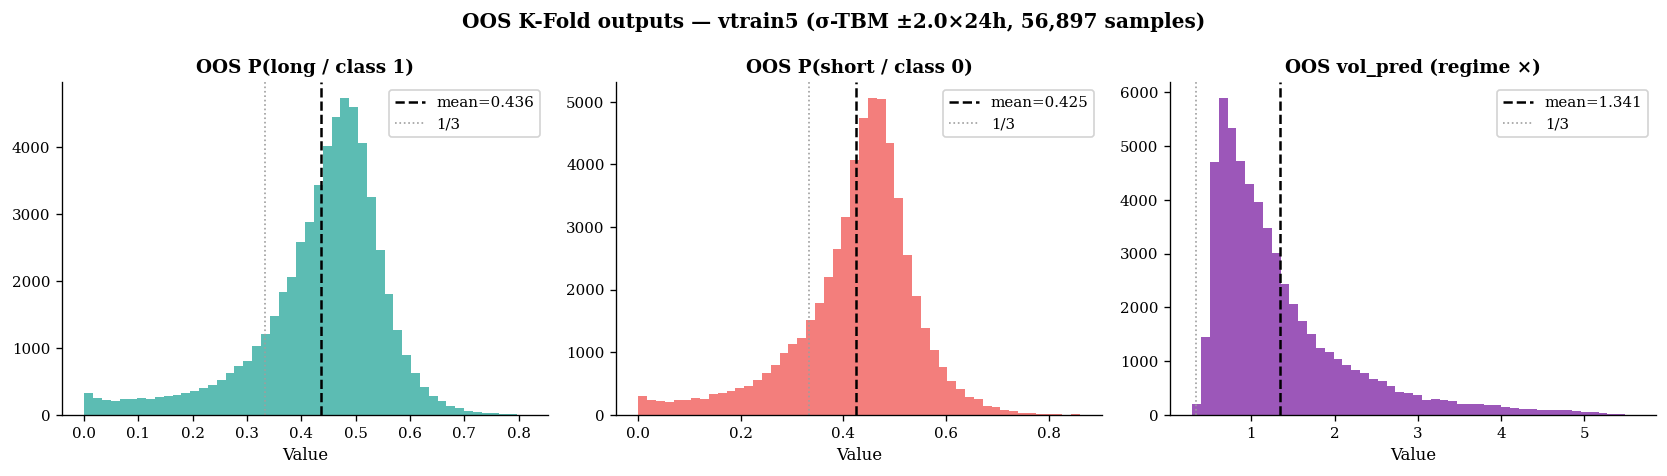

In [6]:
valid_mask    = ~np.isnan(oos_up)
oos_up_v      = oos_up[valid_mask]
oos_down_v    = oos_down[valid_mask]
oos_vol_pred_v = oos_vol_pred[valid_mask]
oos_close_v   = train_close[valid_mask]
oos_high_v    = train_high[valid_mask]
oos_low_v     = train_low[valid_mask]
oos_atr_v     = train_atr[valid_mask]
oos_index_v   = train_index[valid_mask]
bh_oos        = oos_close_v / oos_close_v[0]

print(f'OOS rows: {len(oos_up_v):,}  range: {oos_index_v.min().date()} → {oos_index_v.max().date()}')
print(f'P(up)     mean={oos_up_v.mean():.4f}  std={oos_up_v.std():.4f}')
print(f'P(down)   mean={oos_down_v.mean():.4f}  std={oos_down_v.std():.4f}')
print(f'vol_pred  mean={oos_vol_pred_v.mean():.4f}  std={oos_vol_pred_v.std():.4f}  '
      f'median={np.median(oos_vol_pred_v):.4f}  (target: ~1.0 = median regime)')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, prob, label, color in [
    (axes[0], oos_up_v,        'OOS P(long / class 1)',  GREEN),
    (axes[1], oos_down_v,      'OOS P(short / class 0)', RED),
    (axes[2], oos_vol_pred_v,  'OOS vol_pred (regime ×)', PURPLE),
]:
    ax.hist(prob, bins=50, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(prob.mean(), color='black', ls='--', lw=1.5, label=f'mean={prob.mean():.3f}')
    ax.axvline(1/3, color=GREY, ls=':', lw=1, label='1/3')
    ax.set_xlabel('Value'); ax.legend(); ax.set_title(label, fontweight='bold')
fig.suptitle(f'OOS K-Fold outputs — v5 (σ-TBM ±{TBM_MULT}×{TBM_VOL_WINDOW}h, {len(oos_up_v):,} samples)',
             fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'tcn_oos_prob_distribution_v5.png'); plt.show()

In [7]:
## Phase 2 — Dynamic-Threshold Backtester (Spot/Futures routing)
#
# Key changes vs run_backtest_v4:
#  1. Accepts vol_pred_arr for per-bar threshold adjustment
#  2. long_thr_t  = clip(base_thr − vol_scale × vol_pred_t, 0.20, 0.85)
#     short_thr_t = clip(base_thr + vol_scale × vol_pred_t, 0.15, 0.80)
#  3. Limit price is MULTIPLICATIVE: px*(1−ent_atr*atr)  (v4 had additive bug)

def run_backtest_v5_adaptive(
    probs_up, probs_down, vol_pred_arr,
    close_arr, high_arr, low_arr, atr_arr,
    params,
    maker_fee=MAKER_FEE,
    spot_taker=SPOT_TAKER_FEE, fut_taker=FUTURES_TAKER_FEE,
    buf=BUFFER,
    spot_fund=SPOT_FUNDING_H, short_fund=SHORT_FUNDING_H
):
    base_thr = params['base_threshold']
    vs       = params['vol_scale']
    ent_atr  = params['entry_atr_mult']
    sl_m     = params['sl_atr_multiplier']
    tp_m     = params['tp_atr_multiplier']
    min_hold = int(params['min_hold'])
    max_hold = int(params['max_hold'])
    cd_n     = int(params['cooldown'])

    cash = 1.0; units = 0.0; entry_cash = 0.0
    in_pos = False; direction = None
    entry_px = 0.0; dsl = 0.0; dtp = 0.0
    hold_count = 0; cooldown = 0; entry_bar = -1
    pending = None

    equity = [1.0]; trade_log = []
    n_sig = 0; n_fill = 0; n_exp = 0

    N = len(close_arr)
    for i in range(N):
        px  = close_arr[i]; hi = high_arr[i]; lo = low_arr[i]
        pup = probs_up[i];  pdn = probs_down[i]; atr = atr_arr[i]
        vp  = float(vol_pred_arr[i]) if not np.isnan(vol_pred_arr[i]) else 1.0
        if cooldown > 0: cooldown -= 1

        # Dynamic per-bar thresholds driven by vol prediction
        lt = float(np.clip(base_thr - vs * vp, 0.20, 0.85))
        st = float(np.clip(base_thr + vs * vp, 0.15, 0.80))
        exit_long  = 1.0 - (base_thr - vs * vp)  # symmetric exit w.r.t. entry thr
        exit_short = 1.0 - (base_thr + vs * vp)
        exit_long  = float(np.clip(exit_long,  0.15, 0.80))
        exit_short = float(np.clip(exit_short, 0.20, 0.85))

        # ── 1. Fill check (TIF = 1 bar) ─────────────────────────────────────
        if pending is not None:
            lp = pending['limit_px']
            if pending['direction'] == 'long':
                if lo < lp * (1.0 - buf):
                    units = cash * (1.0 - maker_fee) / lp; cash = 0.0
                    in_pos = True; direction = 'long'; entry_px = lp
                    entry_bar = i; hold_count = 0; dsl = pending['sl']; dtp = pending['tp']
                    n_fill += 1
                else: n_exp += 1
            else:
                if hi > lp * (1.0 + buf):
                    entry_cash = cash * (1.0 - maker_fee); cash = 0.0; units = entry_cash / lp
                    in_pos = True; direction = 'short'; entry_px = lp
                    entry_bar = i; hold_count = 0; dsl = pending['sl']; dtp = pending['tp']
                    n_fill += 1
                else: n_exp += 1
            pending = None

        # ── 2. Manage open position ─────────────────────────────────────────
        if in_pos and i > entry_bar:
            hold_count += 1
            if direction == 'long':    units      *= (1.0 - spot_fund)
            else:                      entry_cash *= (1.0 + short_fund)

            reason = None; exit_px = px; pnl = 0.0
            if direction == 'long':
                sl_price = entry_px * (1.0 - dsl)
                tp_price = entry_px * (1.0 + dtp)
                tp_check = tp_price * (1.0 + buf)
                sl_hit = lo <= sl_price; tp_hit = hi > tp_check
                if sl_hit and tp_hit:      reason = 'sl'; exit_px = sl_price
                elif sl_hit:               reason = 'sl'; exit_px = sl_price
                elif tp_hit:               reason = 'tp'; exit_px = tp_price
                elif hold_count >= max_hold: reason = 'max_hold'
                elif hold_count >= min_hold and pup < exit_long: reason = 'conf'
                if reason:
                    pnl = (exit_px - entry_px) / entry_px
                    fe  = spot_taker if reason != 'tp' else maker_fee
                    cash = units * exit_px * (1.0 - fe); units = 0.0
            else:
                sl_price = entry_px * (1.0 + dsl)
                tp_price = entry_px * (1.0 - dtp)
                tp_check = tp_price * (1.0 - buf)
                sl_hit = hi >= sl_price; tp_hit = lo < tp_check
                if sl_hit and tp_hit:      reason = 'sl'; exit_px = sl_price
                elif sl_hit:               reason = 'sl'; exit_px = sl_price
                elif tp_hit:              reason = 'tp'; exit_px = tp_price
                elif hold_count >= max_hold: reason = 'max_hold'
                elif hold_count >= min_hold and pdn < exit_short: reason = 'conf'
                if reason:
                    gross = (entry_px - exit_px) / entry_px; pnl = gross
                    fe    = fut_taker if reason != 'tp' else maker_fee
                    cash  = entry_cash * (1.0 + gross) * (1.0 - fe)

            if reason:
                trade_log.append({'direction': direction, 'pnl_pct': pnl,
                                   'hold_h': hold_count, 'reason': reason})
                in_pos = False; hold_count = 0; cooldown = cd_n

        # ── 3. Place pending order if flat ───────────────────────────────────
        if not in_pos and pending is None and cooldown == 0:
            sl_v = max(sl_m * atr, MIN_SL); tp_v = tp_m * atr
            if pup >= lt:
                # Multiplicative limit price (fixes v4 additive bug)
                pending = {'direction': 'long',  'limit_px': px * (1.0 - ent_atr * atr),
                           'sl': sl_v, 'tp': tp_v}; n_sig += 1
            elif pdn >= st and pup < lt:
                pending = {'direction': 'short', 'limit_px': px * (1.0 + ent_atr * atr),
                           'sl': sl_v, 'tp': tp_v}; n_sig += 1

        # ── Equity ───────────────────────────────────────────────────────────
        if in_pos and direction == 'long':    equity.append(units * px)
        elif in_pos and direction == 'short': equity.append(entry_cash * (1.0 + (entry_px - px) / entry_px))
        else:                                 equity.append(cash)

    if in_pos:
        px = close_arr[-1]
        if direction == 'long':
            gross = (px - entry_px) / entry_px; cash = units * px * (1 - spot_taker)
        else:
            gross = (entry_px - px) / entry_px; cash = entry_cash * (1 + gross) * (1 - fut_taker)
        trade_log.append({'direction': direction, 'pnl_pct': gross, 'hold_h': hold_count, 'reason': 'eod'})
        equity[-1] = cash

    tdf = pd.DataFrame(trade_log)
    tdf.attrs = {'n_signals': n_sig, 'n_fills': n_fill, 'n_expires': n_exp}
    return np.array(equity[1:]), tdf


def score_eq(eq, tdf, metric):
    if tdf.empty: return -np.inf
    r = np.log(np.maximum(eq[1:],1e-12)/np.maximum(eq[:-1],1e-12)); ann = 24*365
    if metric == 'sharpe':       return float(r.mean()/(r.std(ddof=1)+1e-12)*np.sqrt(ann))
    if metric == 'total_return': return float(eq[-1]-1)
    if metric == 'calmar':
        ar = float((eq[-1]**(ann/len(eq)))-1); pk = np.maximum.accumulate(eq)
        return ar/(abs(float(((eq-pk)/(pk+1e-12)).min()))+1e-6)
    if metric == 'win_rate': return float((tdf['pnl_pct']>0).mean())
    return -np.inf

print('run_backtest_v5_adaptive() defined.')
print(f'Grid: {len(list(itertools.product(*[TRADING_GRID[k] for k in TRADING_GRID])))}')

run_backtest_v5_adaptive() defined.
Grid: 192


In [8]:
keys   = list(TRADING_GRID.keys())
combos = list(itertools.product(*[TRADING_GRID[k] for k in keys]))
print(f'Grid combinations: {len(combos):,}')

results = []
for vals in tqdm(combos, desc='Grid search (OOS, dynamic thr)', ncols=80):
    p = dict(zip(keys, vals))
    eq, tdf = run_backtest_v5_adaptive(
        oos_up_v, oos_down_v, oos_vol_pred_v,
        oos_close_v, oos_high_v, oos_low_v, oos_atr_v, p)
    if len(tdf) < MIN_TRADES: continue

    s  = score_eq(eq, tdf, OPTIMISE_METRIC)
    r  = np.log(np.maximum(eq[1:],1e-12)/np.maximum(eq[:-1],1e-12))
    pk = np.maximum.accumulate(eq)
    fr = tdf.attrs['n_fills'] / max(tdf.attrs['n_signals'], 1)

    results.append({
        **p,
        'score':        s,
        'total_return': float(eq[-1]-1),
        'sharpe':       float(r.mean()/(r.std(ddof=1)+1e-12)*np.sqrt(24*365)),
        'max_dd':       float(((eq-pk)/(pk+1e-12)).min()),
        'n_trades':     len(tdf),
        'win_rate':     float((tdf['pnl_pct']>0).mean()),
        'n_long':       int((tdf['direction']=='long').sum()),
        'n_short':      int((tdf['direction']=='short').sum()),
        'n_sl':         int((tdf['reason']=='sl').sum()),
        'n_tp':         int((tdf['reason']=='tp').sum()),
        'fill_rate':    fr,
    })

results_df = pd.DataFrame(results).sort_values('score', ascending=False).reset_index(drop=True)
print(f'\nValid (≥{MIN_TRADES} trades): {len(results_df):,}/{len(combos):,}')
if not results_df.empty:
    print(f'Best {OPTIMISE_METRIC}    : {results_df["score"].iloc[0]:.4f}')
    print(f'Fill rate     : mean={results_df["fill_rate"].mean():.1%}')

Grid combinations: 192


Grid search (OOS, dynamic thr): 100%|█████████| 192/192 [18:01<00:00,  5.63s/it]


Valid (≥30 trades): 192/192
Best sharpe    : 0.4250
Fill rate     : mean=50.9%


In [9]:
from IPython.display import display

disp = ['score','total_return','sharpe','max_dd','win_rate','fill_rate',
        'n_trades','n_long','n_short','n_sl','n_tp',
        'base_threshold','vol_scale','entry_atr_mult',
        'sl_atr_multiplier','tp_atr_multiplier','min_hold','max_hold','cooldown']
top = results_df[[c for c in disp if c in results_df.columns]].head(TOP_N).copy()
for col, fmt in [('total_return','{:+.2%}'),('max_dd','{:.2%}'),('win_rate','{:.1%}'),
                 ('fill_rate','{:.1%}'),('score','{:.4f}'),('sharpe','{:.3f}')]:
    if col in top.columns: top[col] = top[col].map(fmt.format)

best        = results_df.iloc[0]
best_params = {k: best[k] for k in keys}

print(f'Top {TOP_N} by {OPTIMISE_METRIC}  (TCN v5 — dynamic σ-TBM):\n')
print(top.to_string(index=True))
print(f'\n── Best config ──────────────────────────────────────────')
for k, v in best_params.items(): print(f'  {k:<24}: {v}')
print(f'  {"OOS Sharpe":<24}: {best["sharpe"]:.4f}')
print(f'  {"OOS Return":<24}: {best["total_return"]:+.2%}')
print(f'  {"OOS MaxDD":<24}: {best["max_dd"]:.2%}')
print(f'  {"OOS Trades":<24}: {int(best["n_trades"])}  (fill rate: {best["fill_rate"]:.1%})')

Top 20 by sharpe  (TCN vtrain5 — dynamic σ-TBM):

     score total_return sharpe   max_dd win_rate fill_rate  n_trades  n_long  n_short  n_sl  n_tp  base_threshold  vol_scale  entry_atr_mult  sl_atr_multiplier  tp_atr_multiplier  min_hold  max_hold  cooldown
0   0.4250     +270.44%  0.425  -63.74%    52.1%     39.6%      2220    2010      210   681   327            0.55       0.05             0.4                2.0                3.0         8        48         4
1   0.4239     +293.21%  0.424  -57.02%    53.4%     65.0%      2328    2080      248   857   895            0.55       0.05             0.2                2.0                2.0        16        48         4
2   0.3883     +211.20%  0.388  -61.75%    54.2%     39.8%      2349    2127      222   692   681            0.55       0.05             0.4                2.0                2.0         8        48         4
3   0.3823     +236.77%  0.382  -60.88%    43.3%     39.6%      2011    1806      205  1016   457            0.55 

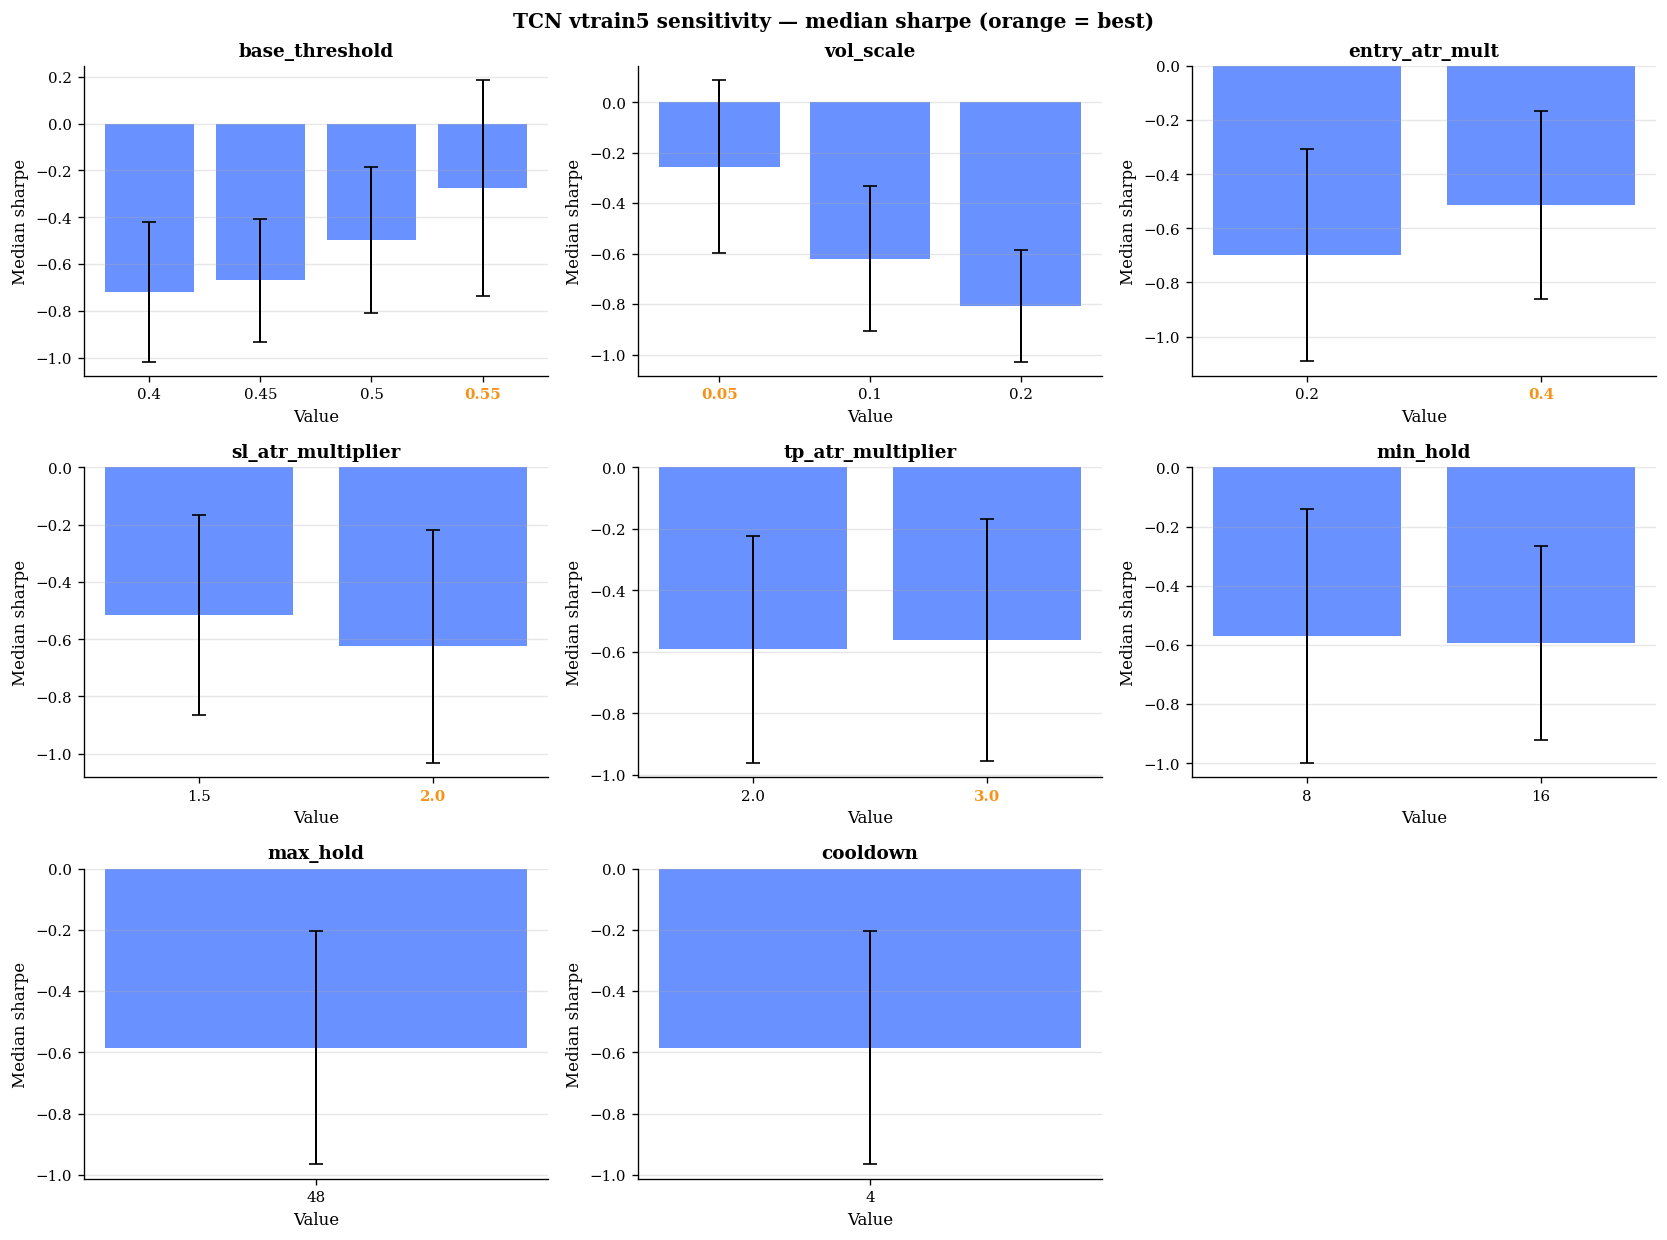

In [10]:
if not results_df.empty:
    n_p = len(keys); ncols = 3; nrows = int(np.ceil(n_p / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows*3.5))
    for ax, param in zip(axes.flat, keys):
        grp = results_df.groupby(param)['score'].agg(['median','std']).reset_index()
        x   = grp[param].astype(str)
        ax.bar(x, grp['median'], color=BLUE, alpha=0.7)
        ax.errorbar(x, grp['median'], yerr=grp['std'],
                    fmt='none', color='black', capsize=4, lw=1.2)
        ax.set_title(param, fontweight='bold')
        ax.set_xlabel('Value'); ax.set_ylabel(f'Median {OPTIMISE_METRIC}')
        ax.grid(axis='y', alpha=0.3)
        bv = str(best[param])
        for tick in ax.get_xticklabels():
            if tick.get_text() == bv: tick.set_color(ACCENT); tick.set_fontweight('bold')
    for ax in axes.flat[n_p:]: ax.set_visible(False)
    fig.suptitle(f'TCN v5 sensitivity — median {OPTIMISE_METRIC} (orange = best)', fontweight='bold')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'tcn_grid_sensitivity_v5.png'); plt.show()

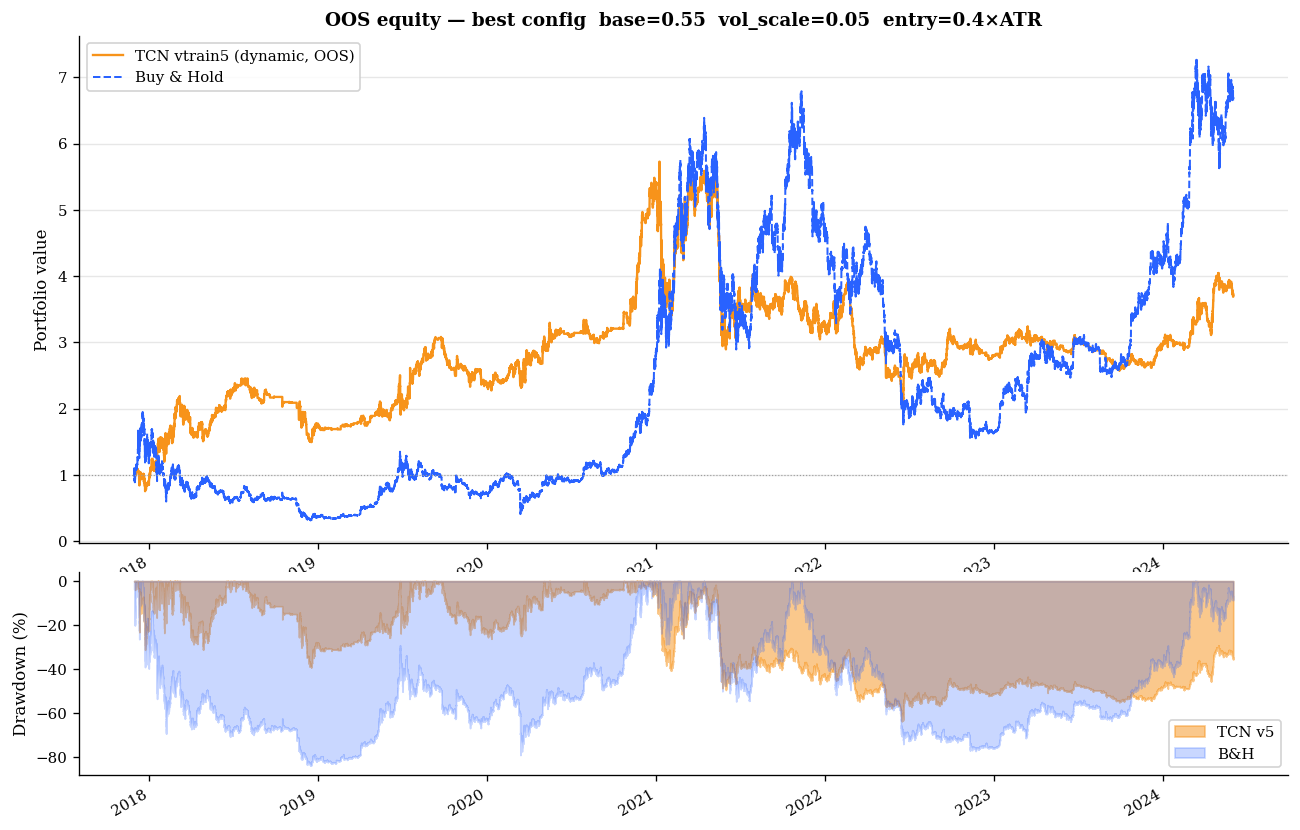

OOS  Sharpe=0.425  Return=+270.44%  MaxDD=-63.74%  Trades=2220  FillRate=39.6%


In [11]:
if not results_df.empty:
    eq_oos, tdf_oos = run_backtest_v5_adaptive(
        oos_up_v, oos_down_v, oos_vol_pred_v,
        oos_close_v, oos_high_v, oos_low_v, oos_atr_v, best_params)

    fig, axes = plt.subplots(2, 1, figsize=(13, 8),
                              gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.08})
    ax = axes[0]
    ax.plot(oos_index_v, eq_oos, color=ACCENT, lw=1.4, label='TCN v5 (dynamic, OOS)')
    ax.plot(oos_index_v, bh_oos, color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
    ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
    ax.set_ylabel('Portfolio value')
    ax.set_title(f'OOS equity — best config  base={best_params["base_threshold"]}  '
                 f'vol_scale={best_params["vol_scale"]}  '
                 f'entry={best_params["entry_atr_mult"]}×ATR', fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.3)

    ax = axes[1]
    pk_s = np.maximum.accumulate(eq_oos); pk_b = np.maximum.accumulate(bh_oos)
    ax.fill_between(oos_index_v, (eq_oos-pk_s)/(pk_s+1e-12)*100, 0, color=ACCENT, alpha=0.5, label='TCN v5')
    ax.fill_between(oos_index_v, (bh_oos-pk_b)/(pk_b+1e-12)*100, 0, color=BLUE,  alpha=0.25, label='B&H')
    ax.set_ylabel('Drawdown (%)'); ax.legend()
    for ax in axes:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'tcn_grid_oos_equity_v5.png'); plt.show()

    rr = np.log(np.maximum(eq_oos[1:],1e-12)/np.maximum(eq_oos[:-1],1e-12))
    pk = np.maximum.accumulate(eq_oos)
    print(f'OOS  Sharpe={rr.mean()/(rr.std(ddof=1)+1e-12)*np.sqrt(24*365):.3f}  '
          f'Return={eq_oos[-1]-1:+.2%}  MaxDD={((eq_oos-pk)/(pk+1e-12)).min():.2%}  '
          f'Trades={len(tdf_oos)}  FillRate={tdf_oos.attrs["n_fills"]/max(tdf_oos.attrs["n_signals"],1):.1%}')

In [12]:
## Phase 3a — Train Production Model on Full Trainval
#
# QT fitted on train_df only (val_df used only for early stopping).
# This model's backbone (model.tcn) will be frozen for WFO in Phase 3b.

if results_df.empty:
    raise RuntimeError('Grid search produced no results — cannot train production model.')

print('Training production model on full train_df + val_df early-stop...')

qt_prod = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=SEED)
qt_prod.fit(train_df[ALL_INPUT_FEATS].values)
X_prod_qt = qt_prod.transform(train_df[ALL_INPUT_FEATS].values).astype(np.float32)

y_prod = train_df['tbm_label'].values.astype(np.int64)
w_prod = train_df['sample_weight'].values.astype(np.float32)
v_prod = train_df['fwd_vol_norm'].values.astype(np.float32)

X_fs, y_fs, w_fs, v_fs = [], [], [], []
for i in range(SEQ_LEN-1, len(X_prod_qt)):
    X_fs.append(X_prod_qt[i-SEQ_LEN+1:i+1])
    y_fs.append(y_prod[i]); w_fs.append(w_prod[i]); v_fs.append(v_prod[i])
X_full = torch.tensor(np.array(X_fs, dtype=np.float32))
y_full = torch.tensor(np.array(y_fs, dtype=np.int64))
w_full = torch.tensor(np.array(w_fs, dtype=np.float32))
v_full = torch.tensor(np.array(v_fs, dtype=np.float32))
print(f'Full-train sequences: {len(X_full):,}')

ccs = np.bincount(y_full.numpy(), minlength=3).astype(np.float32)
cw  = torch.tensor(ccs.sum()/(3*ccs+1e-8), dtype=torch.float32).to(DEVICE)

X_val_raw  = qt_prod.transform(val_df[ALL_INPUT_FEATS].values).astype(np.float32)
X_val_seqs = np.stack([X_val_raw[i:i+SEQ_LEN]
                        for i in range(len(X_val_raw)-SEQ_LEN+1)]).astype(np.float32)
y_val_prod = val_df['tbm_label'].values[SEQ_LEN-1:].astype(np.int64)
v_val_prod = val_df['fwd_vol_norm'].values[SEQ_LEN-1:].astype(np.float32)
assert len(X_val_seqs) == len(y_val_prod) == len(v_val_prod), \
    f'Val size mismatch: X={len(X_val_seqs)} y={len(y_val_prod)} v={len(v_val_prod)}'
X_val_t = torch.from_numpy(X_val_seqs)
y_val_t = torch.from_numpy(y_val_prod)
v_val_t = torch.from_numpy(v_val_prod)
print(f'Val sequences: {len(X_val_t):,}')

model_prod = TCNMultiTask(n_feats, TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).to(DEVICE)
opt_prod   = torch.optim.AdamW(model_prod.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched_prod = torch.optim.lr_scheduler.LambdaLR(
    opt_prod, lr_lambda=make_lr_lambda(EPOCHS_PROD, WARMUP_EPOCHS))

loader_full = DataLoader(TensorDataset(X_full, y_full, w_full, v_full),
                          batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=0)
loader_val  = DataLoader(TensorDataset(X_val_t, y_val_t,
                                        torch.ones(len(y_val_t)), v_val_t),
                          batch_size=512, shuffle=False, num_workers=0)

PATIENCE_PROD = 15; best_val = np.inf; pat = 0; best_prod_state = None
for epoch in range(EPOCHS_PROD):
    model_prod.train()
    for xb, yb, wb, vb in loader_full:
        xb,yb,wb,vb = xb.to(DEVICE),yb.to(DEVICE),wb.to(DEVICE),vb.to(DEVICE)
        opt_prod.zero_grad()
        lgts, vp = model_prod(xb)
        loss = (F.cross_entropy(lgts,yb,weight=cw,reduction='none')*wb).mean() + \
               LAMBDA_VOL*(F.huber_loss(vp,vb,reduction='none')*wb).mean()
        loss.backward(); torch.nn.utils.clip_grad_norm_(model_prod.parameters(),1.0); opt_prod.step()
    sched_prod.step()
    model_prod.eval(); va = 0.0
    with torch.no_grad():
        for xb,yb,_,vb in loader_val:
            xb,yb,vb = xb.to(DEVICE),yb.to(DEVICE),vb.to(DEVICE)
            lgts,vp  = model_prod(xb)
            va += (F.cross_entropy(lgts,yb)+LAMBDA_VOL*F.huber_loss(vp,vb)).item()*len(xb)
    vl = va / max(len(loader_val.dataset), 1)
    if vl < best_val: best_val=vl; best_prod_state={kk:vv.cpu().clone() for kk,vv in model_prod.state_dict().items()}; pat=0
    else: pat+=1
    if pat >= PATIENCE_PROD: print(f'Early stop ep {epoch+1}  best_val={best_val:.5f}'); break
    if (epoch+1)%10==0: print(f'Ep {epoch+1}/{EPOCHS_PROD}  val={vl:.5f}  best={best_val:.5f}  pat={pat}')

model_prod.load_state_dict(best_prod_state)
torch.save(model_prod.state_dict(), MODELS_DIR / 'tcn_model_v5.pt')
with open(MODELS_DIR / 'tcn_qt_v5.pkl', 'wb') as f: pickle.dump(qt_prod, f)
print(f'Saved: tcn_model_v5.pt  tcn_qt_v5.pkl')
model_prod.cpu()
if DEVICE.type=='mps': torch.mps.empty_cache()

Training production model on full train_df + val_df early-stop...
Full-train sequences: 56,902
Val sequences: 5,089
Ep 10/80  val=0.97257  best=0.95297  pat=1
Ep 20/80  val=1.01002  best=0.93824  pat=7
Early stop ep 28  best_val=0.93824
Saved: tcn_model_vtrain5.pt  tcn_qt_vtrain5.pkl


In [13]:
## Phase 3b — Frozen-Backbone WFO Test Inference
#
# Protocol:
#  1. Load prod model; freeze backbone (model.tcn) parameters.
#  2. Build full_df = concat(train_df, val_df, test_df) — needed for trailing windows.
#  3. For each WFO step (every WFO_STEP_H=720 bars):
#     a. Extract embeddings from trailing WFO_LOOKBACK_H=2160 bars via frozen backbone.
#     b. Reset head weights (fresh Xavier init).
#     c. Train heads only for WFO_EPOCHS=5 epochs, LR=1e-4.
#     d. Predict next WFO_STEP_H bars using updated heads.

# ── Load prod model ───────────────────────────────────────────────────────────
wfo_model = TCNMultiTask(n_feats, TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).to(DEVICE)
wfo_model.load_state_dict(torch.load(MODELS_DIR / 'tcn_model_v5.pt', map_location=DEVICE))
wfo_model.eval()

# Freeze backbone
for p in wfo_model.tcn.parameters():
    p.requires_grad = False

qt_wfo = pickle.loads((MODELS_DIR / 'tcn_qt_v5.pkl').read_bytes())

# ── Full data (trainval + test) for embedding / retraining windows ───────────
trainval_df = pd.concat([train_df, val_df])
full_df     = pd.concat([trainval_df, test_df])
full_X_raw  = qt_wfo.transform(full_df[ALL_INPUT_FEATS].values).astype(np.float32)
full_y      = full_df['tbm_label'].values.astype(np.int64)
full_w      = full_df['sample_weight'].values.astype(np.float32)
full_v      = full_df['fwd_vol_norm'].values.astype(np.float32)
N_TRAINVAL  = len(trainval_df)
N_TEST      = len(test_df)
N_FULL      = len(full_df)

test_up_wfo   = np.full(N_TEST, np.nan, dtype=np.float32)
test_down_wfo = np.full(N_TEST, np.nan, dtype=np.float32)
test_vol_wfo  = np.full(N_TEST, np.nan, dtype=np.float32)

# ── Helper: reset head weights ────────────────────────────────────────────────
def _reset_heads(model):
    def _r(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
    model.head_dir.apply(_r); model.head_vol.apply(_r)

# ── Helper: extract backbone embeddings (frozen, no_grad) ─────────────────────
def _extract_embeddings(model, X_raw, global_indices, batch_sz=512):
    seqs = []
    valid_gidx = []
    for j in global_indices:
        if j < SEQ_LEN - 1: continue
        seqs.append(X_raw[j - SEQ_LEN + 1 : j + 1])
        valid_gidx.append(j)
    if not seqs:
        return torch.empty(0, TCN_CHANNELS[-1]), []
    X_t = torch.from_numpy(np.array(seqs, dtype=np.float32))
    embs = []
    model.eval()
    with torch.no_grad():
        for xb, in DataLoader(TensorDataset(X_t), batch_size=batch_sz):
            h = model.tcn(xb.to(DEVICE).transpose(1, 2))  # (B, C, T)
            embs.append(h[:, :, -1].cpu())                 # last causal step → (B, C)
    return torch.cat(embs), valid_gidx

# ── WFO loop ──────────────────────────────────────────────────────────────────
wfo_starts = list(range(0, N_TEST, WFO_STEP_H))
wfo_ends   = wfo_starts[1:] + [N_TEST]

ccs_full = np.bincount(full_y[full_y >= 0], minlength=3).astype(np.float32)
cw_full  = torch.tensor(ccs_full.sum()/(3*ccs_full+1e-8), dtype=torch.float32).to(DEVICE)

for step_i, (t_start, t_end) in enumerate(zip(wfo_starts, wfo_ends)):
    g_step_start = N_TRAINVAL + t_start   # global index into full_df

    # ── Collect trailing lookback for head retraining ─────────────────────────
    lb_start = max(SEQ_LEN - 1, g_step_start - WFO_LOOKBACK_H)
    lb_end   = g_step_start
    lb_gidx  = [j for j in range(lb_start, lb_end) if full_y[j] in (0, 1, 2)]

    if lb_gidx:
        embs, valid_gidx = _extract_embeddings(wfo_model, full_X_raw, lb_gidx)
        if len(embs) >= 32:
            y_lb = torch.tensor([full_y[j] for j in valid_gidx], dtype=torch.int64)
            w_lb = torch.tensor([full_w[j] for j in valid_gidx], dtype=torch.float32)
            v_lb = torch.tensor([full_v[j] for j in valid_gidx], dtype=torch.float32)

            _reset_heads(wfo_model)

            head_params = (list(wfo_model.head_dir.parameters()) +
                           list(wfo_model.head_vol.parameters()))
            opt_wfo     = torch.optim.AdamW(head_params, lr=LR_WFO)
            ds_wfo      = TensorDataset(embs, y_lb, w_lb, v_lb)
            ld_wfo      = DataLoader(ds_wfo, batch_size=256, shuffle=True, drop_last=False)

            wfo_model.train()
            for _ in range(WFO_EPOCHS):
                for eb, yb, wb, vb in ld_wfo:
                    eb,yb,wb,vb = eb.to(DEVICE),yb.to(DEVICE),wb.to(DEVICE),vb.to(DEVICE)
                    opt_wfo.zero_grad()
                    lgts = wfo_model.head_dir(eb)
                    vp   = wfo_model.head_vol(eb).squeeze(-1)
                    loss = (F.cross_entropy(lgts,yb,weight=cw_full,reduction='none')*wb).mean() + \
                           LAMBDA_VOL*(F.huber_loss(vp,vb,reduction='none')*wb).mean()
                    loss.backward(); opt_wfo.step()

    # ── Predict this WFO step ─────────────────────────────────────────────────
    g_pred_start = N_TRAINVAL + t_start
    g_pred_end   = N_TRAINVAL + t_end
    pred_gidx    = list(range(max(g_pred_start, SEQ_LEN - 1), g_pred_end))

    if pred_gidx:
        pred_seqs = [full_X_raw[j - SEQ_LEN + 1 : j + 1] for j in pred_gidx]
        X_pred    = torch.from_numpy(np.array(pred_seqs, dtype=np.float32))
        wfo_model.eval(); ll_d = []; ll_v = []
        with torch.no_grad():
            for xb, in DataLoader(TensorDataset(X_pred), batch_size=512):
                lgts, vp = wfo_model(xb.to(DEVICE))
                ll_d.append(lgts.cpu()); ll_v.append(vp.cpu())
        probs = torch.softmax(torch.cat(ll_d), dim=1).numpy()
        vols  = torch.cat(ll_v).numpy()
        for local_j, (gj, pd_, pu, vv) in enumerate(zip(
                pred_gidx, probs[:,0], probs[:,1], vols)):
            ti = gj - N_TRAINVAL   # index into test_df
            if 0 <= ti < N_TEST:
                test_down_wfo[ti] = pd_
                test_up_wfo[ti]   = pu
                test_vol_wfo[ti]  = vv

    n_ret = int((~np.isnan(test_up_wfo[:t_end])).sum())
    print(f'WFO step {step_i+1}/{len(wfo_starts)}  '
          f'test[{t_start}:{t_end}]  '
          f'retrain_rows={len(lb_gidx) if lb_gidx else 0}  '
          f'preds_so_far={n_ret}')

# ── Extract test arrays for backtesting ──────────────────────────────────────
wfo_valid = ~np.isnan(test_up_wfo)
test_up_v   = test_up_wfo[wfo_valid]
test_down_v = test_down_wfo[wfo_valid]
test_vol_v  = test_vol_wfo[wfo_valid]
test_close_v = test_df['close'].values[wfo_valid].astype(np.float64)
test_high_v  = test_df['high'].values[wfo_valid].astype(np.float64)
test_low_v   = test_df['low'].values[wfo_valid].astype(np.float64)
test_atr_v   = test_df['atr_14_pct'].values[wfo_valid].astype(np.float64)
test_index_v = test_df.index[wfo_valid]
test_bh      = test_close_v / test_close_v[0]

print(f'\nWFO coverage: {wfo_valid.sum():,}/{N_TEST:,}  '
      f'period: {test_index_v.min().date()} → {test_index_v.max().date()}')
print(f'vol_pred  mean={test_vol_v.mean():.4f}  std={test_vol_v.std():.4f}')

wfo_model.cpu(); del wfo_model
if DEVICE.type=='mps': torch.mps.empty_cache()
elif DEVICE.type=='cuda': torch.cuda.empty_cache()

WFO step 1/17  test[0:720]  retrain_rows=2160  preds_so_far=720
WFO step 2/17  test[720:1440]  retrain_rows=2160  preds_so_far=1440
WFO step 3/17  test[1440:2160]  retrain_rows=2160  preds_so_far=2160
WFO step 4/17  test[2160:2880]  retrain_rows=2160  preds_so_far=2880
WFO step 5/17  test[2880:3600]  retrain_rows=2160  preds_so_far=3600
WFO step 6/17  test[3600:4320]  retrain_rows=2160  preds_so_far=4320
WFO step 7/17  test[4320:5040]  retrain_rows=2160  preds_so_far=5040
WFO step 8/17  test[5040:5760]  retrain_rows=2160  preds_so_far=5760
WFO step 9/17  test[5760:6480]  retrain_rows=2160  preds_so_far=6480
WFO step 10/17  test[6480:7200]  retrain_rows=2160  preds_so_far=7200
WFO step 11/17  test[7200:7920]  retrain_rows=2160  preds_so_far=7920
WFO step 12/17  test[7920:8640]  retrain_rows=2160  preds_so_far=8640
WFO step 13/17  test[8640:9360]  retrain_rows=2160  preds_so_far=9360
WFO step 14/17  test[9360:10080]  retrain_rows=2160  preds_so_far=10080
WFO step 15/17  test[10080:10800]

In [14]:
# ── Test backtest ─────────────────────────────────────────────────────────────
eq_v5, tdf_v5 = run_backtest_v5_adaptive(
    test_up_v, test_down_v, test_vol_v,
    test_close_v, test_high_v, test_low_v, test_atr_v, best_params)

def full_metrics(eq, tdf, label):
    r   = np.log(np.maximum(eq[1:],1e-12)/np.maximum(eq[:-1],1e-12))
    pk  = np.maximum.accumulate(eq)
    sh  = float(r.mean()/(r.std(ddof=1)+1e-12)*np.sqrt(24*365))
    mdd = float(((eq-pk)/(pk+1e-12)).min())
    an  = float((eq[-1]**(24*365/len(eq)))-1)
    wr  = float((tdf['pnl_pct']>0).mean()) if not tdf.empty else float('nan')
    pf  = 0.0
    if not tdf.empty:
        g = tdf[tdf['pnl_pct']>0]['pnl_pct'].sum()
        l = tdf[tdf['pnl_pct']<0]['pnl_pct'].abs().sum()
        pf = g/(l+1e-6)
    fr = tdf.attrs.get('n_fills',0)/max(tdf.attrs.get('n_signals',1),1) if tdf.attrs else float('nan')
    return {
        'Strategy':      label,
        'Total Return':  f'{eq[-1]-1:+.2%}',
        'Ann. Return':   f'{an:+.2%}',
        'Sharpe (ann.)': f'{sh:.3f}',
        'Max Drawdown':  f'{mdd:.2%}',
        'Win Rate':      f'{wr:.1%}' if not np.isnan(wr) else 'N/A',
        'Profit Factor': f'{pf:.3f}',
        'Trades':        str(len(tdf)),
    }

summary = pd.DataFrame([
    {'Strategy': 'v1 (close-only, 0% fees)',                   'Total Return': '+11.68%', 'Ann. Return': 'N/A', 'Sharpe (ann.)': '0.446',  'Max Drawdown': '-19.08%', 'Win Rate': '60.0%', 'Profit Factor': 'N/A', 'Trades': '75'},
    {'Strategy': 'v2 static (TBM 1×σ, 0.1% flat)',             'Total Return': '-34.00%', 'Ann. Return': 'N/A', 'Sharpe (ann.)': '-4.006', 'Max Drawdown': '-34.54%', 'Win Rate': '52.7%', 'Profit Factor': 'N/A', 'Trades': '205'},
    {'Strategy': 'v2 WFO (TBM 1×σ, 5-ep retrain, 0.1%)',      'Total Return': '-88.52%', 'Ann. Return': 'N/A', 'Sharpe (ann.)': '-10.703','Max Drawdown': '-88.56%', 'Win Rate': '46.9%', 'Profit Factor': 'N/A', 'Trades': '933'},
    {'Strategy': 'v3 maker (TBM 1×σ, maker entry, asym fees)', 'Total Return': '-71.55%', 'Ann. Return': 'N/A', 'Sharpe (ann.)': '-2.602', 'Max Drawdown': '-74.03%', 'Win Rate': '48.2%', 'Profit Factor': 'N/A', 'Trades': '620'},
    {'Strategy': 'v4 (TBM ±2×ATR, Spot/Fut routing)',          'Total Return': '—',       'Ann. Return': '—',   'Sharpe (ann.)': '—',      'Max Drawdown': '—',       'Win Rate': '—',     'Profit Factor': '—',   'Trades': '—'},
    full_metrics(eq_v5, tdf_v5, f'v5 (σ-TBM ±{TBM_MULT}×{TBM_VOL_WINDOW}h, WFO)'),
    full_metrics(test_bh, pd.DataFrame(), 'Buy & Hold'),
]).set_index('Strategy')

print('\n' + '='*90)
print('  FINAL TEST-SET SUMMARY — TCN v5')
print('='*90)
print(summary.to_string())
print('='*90)

if not tdf_v5.empty:
    print(f'\n  v5 exit breakdown:')
    for r, grp in tdf_v5.groupby('reason'):
        wr_r = (grp['pnl_pct']>0).mean()*100
        print(f'    {r:<12}  n={len(grp):>3}  win={wr_r:.1f}%  avg={grp["pnl_pct"].mean()*100:+.2f}%')
    long_trades  = tdf_v5[tdf_v5['direction']=='long']
    short_trades = tdf_v5[tdf_v5['direction']=='short']
    print(f'\n  Long/Short split: {len(long_trades)} longs / {len(short_trades)} shorts')
    if len(long_trades):  print(f'    Long  avg P&L: {long_trades["pnl_pct"].mean()*100:+.2f}%')
    if len(short_trades): print(f'    Short avg P&L: {short_trades["pnl_pct"].mean()*100:+.2f}%')
    print(f'  Fill rate: {tdf_v5.attrs["n_fills"]}/{tdf_v5.attrs["n_signals"]} signals = '
          f'{tdf_v5.attrs["n_fills"]/max(tdf_v5.attrs["n_signals"],1):.1%}')


  FINAL TEST-SET SUMMARY — TCN vtrain5
                                                Total Return Ann. Return Sharpe (ann.) Max Drawdown Win Rate Profit Factor Trades
Strategy                                                                                                                         
vtrain1 (close-only, 0% fees)                        +11.68%         N/A         0.446      -19.08%    60.0%           N/A     75
vtrain2 static (TBM 1×σ, 0.1% flat)                  -34.00%         N/A        -4.006      -34.54%    52.7%           N/A    205
vtrain2 WFO (TBM 1×σ, 5-ep retrain, 0.1%)            -88.52%         N/A       -10.703      -88.56%    46.9%           N/A    933
vtrain3 maker (TBM 1×σ, maker entry, asym fees)      -71.55%         N/A        -2.602      -74.03%    48.2%           N/A    620
vtrain4 (TBM ±2×ATR, Spot/Fut routing)                     —           —             —            —        —             —      —
vtrain5 (σ-TBM ±2.0×24h, WFO)                     

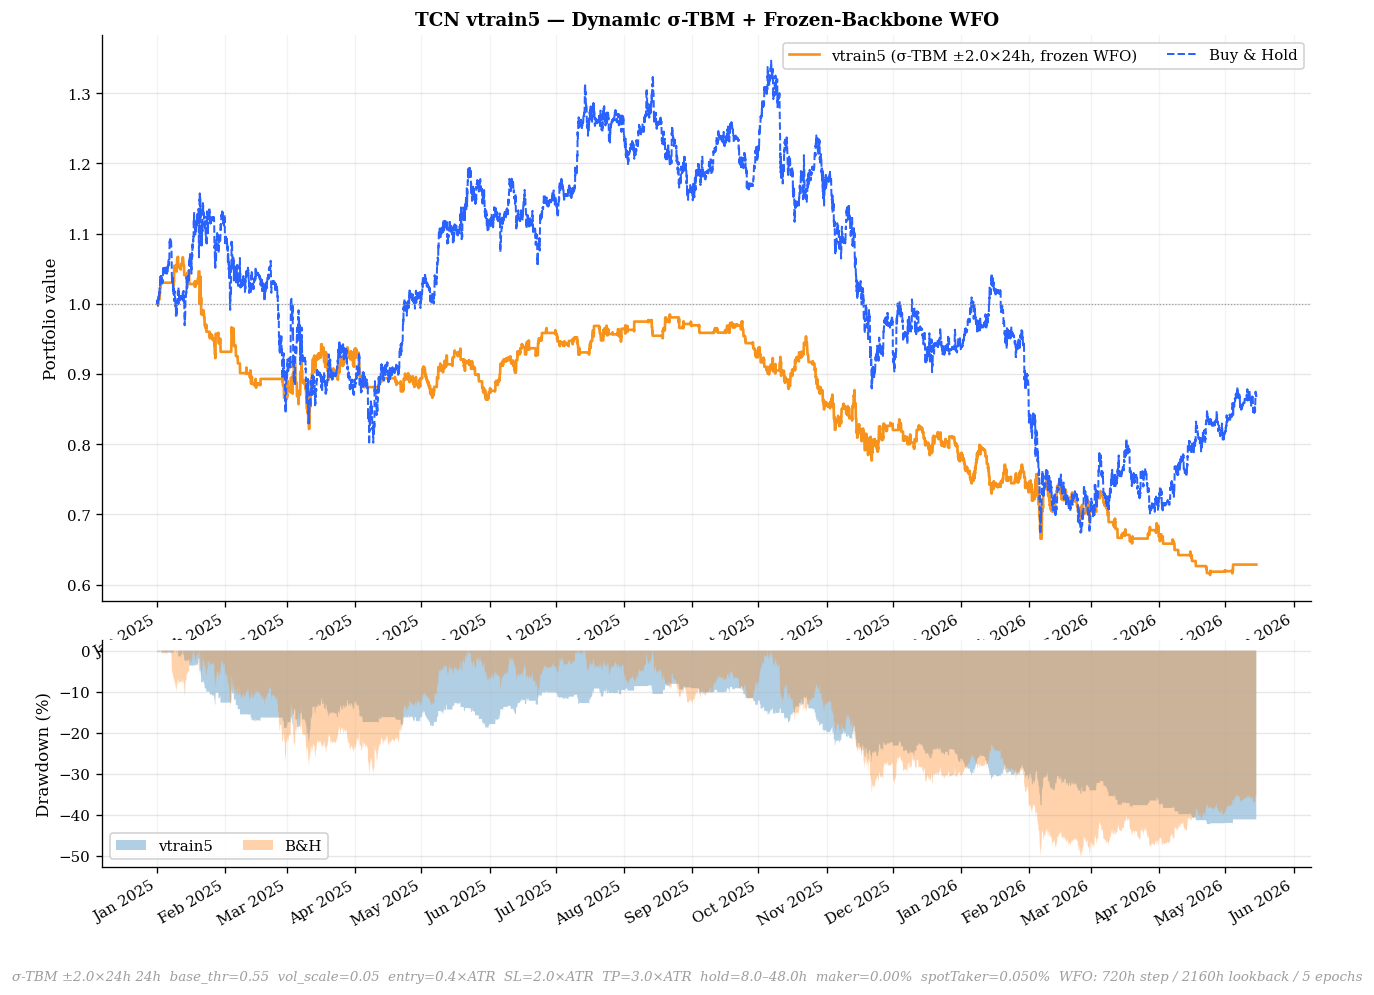

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9),
                          gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.10})
ax = axes[0]
ax.plot(test_index_v, eq_v5,   color=ACCENT, lw=1.6,
        label=f'v5 (σ-TBM ±{TBM_MULT}×{TBM_VOL_WINDOW}h, frozen WFO)')
ax.plot(test_index_v, test_bh, color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
ax.set_ylabel('Portfolio value')
ax.set_title('TCN v5 — Dynamic σ-TBM + Frozen-Backbone WFO', fontweight='bold')
ax.legend(ncol=2); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

ax = axes[1]
for eq, idx, color, lbl in [
    (eq_v5,   test_index_v, ACCENT, 'v5'),
    (test_bh, test_index_v, BLUE,   'B&H'),
]:
    pk = np.maximum.accumulate(eq)
    ax.fill_between(idx, (eq-pk)/(pk+1e-12)*100, 0, alpha=0.35, label=lbl)
ax.set_ylabel('Drawdown (%)'); ax.legend(ncol=2)
ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.text(0.5, 0.005,
    f'σ-TBM ±{TBM_MULT}×{TBM_VOL_WINDOW}h {TBM_VERT_H}h  '
    f'base_thr={best_params["base_threshold"]}  vol_scale={best_params["vol_scale"]}  '
    f'entry={best_params["entry_atr_mult"]}×ATR  SL={best_params["sl_atr_multiplier"]}×ATR  '
    f'TP={best_params["tp_atr_multiplier"]}×ATR  '
    f'hold={best_params["min_hold"]}–{best_params["max_hold"]}h  '
    f'maker={MAKER_FEE*100:.2f}%  spotTaker={SPOT_TAKER_FEE*100:.3f}%  '
    f'WFO: {WFO_STEP_H}h step / {WFO_LOOKBACK_H}h lookback / {WFO_EPOCHS} epochs',
    ha='center', fontsize=8, color=GREY, style='italic')
fig.savefig(FIGURES_DIR / 'tcn_backtest_results_v5.png'); plt.show()

In [16]:
if not results_df.empty:
    out_csv = MODELS_DIR / 'tcn_grid_results_v5.csv'
    results_df.sort_values(OPTIMISE_METRIC, ascending=False).to_csv(out_csv, index=False)
    print(f'Saved: {out_csv}')

    def _s(eq):
        r = np.log(np.maximum(eq[1:],1e-12)/np.maximum(eq[:-1],1e-12))
        return float(r.mean()/(r.std(ddof=1)+1e-12)*np.sqrt(24*365))
    def _d(eq):
        pk = np.maximum.accumulate(eq); return float(((eq-pk)/(pk+1e-12)).min())

    out = {
        'version': 'v5',
        'changes_vs_v4': [
            f'Feature set: ALL {len(ALL_INPUT_FEATS)} features (v4 used ~35 selected)',
            f'SEQ_LEN: {SEQ_LEN} (v4 was 24)',
            f'TCN_DROPOUT: {TCN_DROPOUT} (v4 was 0.40)',
            'QT: per-fold on training rows only (v4 fitted once on full train_df)',
            f'TBM: ±{TBM_MULT}×{TBM_VOL_WINDOW}h-σ {TBM_VERT_H}h vertical (v4 was ±2×ATR14 24h)',
            'Vol target: current normalized σ/median (v4 was forward 6h σ)',
            'Limit price: px*(1-ent_atr*atr) — multiplicative fix for v4 additive bug',
            'Thresholding: dynamic (base ± vol_scale×vol_pred) with per-bar clipping',
            f'Production: frozen-backbone WFO — {WFO_STEP_H}h steps, '
            f'{WFO_LOOKBACK_H}h lookback, {WFO_EPOCHS} head-only epochs (v4 was static)',
        ],
        'architecture': {
            'channels': TCN_CHANNELS, 'kernel': TCN_KERNEL, 'dropout': TCN_DROPOUT,
            'seq_len': SEQ_LEN, 'n_feats': n_feats,
            'n_params': sum(p.numel() for p in
                TCNMultiTask(n_feats, TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).parameters()),
        },
        'tbm': {'vol_window': TBM_VOL_WINDOW, 'mult': TBM_MULT, 'horizon': TBM_VERT_H},
        'execution': {
            'maker_fee': MAKER_FEE, 'spot_taker_fee': SPOT_TAKER_FEE,
            'futures_taker_fee': FUTURES_TAKER_FEE, 'buffer': BUFFER,
            'spot_funding_h': SPOT_FUNDING_H, 'short_funding_h': SHORT_FUNDING_H,
        },
        'wfo': {
            'step_h': WFO_STEP_H, 'lookback_h': WFO_LOOKBACK_H,
            'epochs': WFO_EPOCHS, 'lr': LR_WFO,
        },
        'best_params': {k: float(v) if isinstance(v, float) else v for k, v in best_params.items()},
        'oos_kfold': {
            'sharpe':       round(float(best['sharpe']), 4),
            'total_return': round(float(best['total_return']), 4),
            'max_dd':       round(float(best['max_dd']), 4),
            'n_trades':     int(best['n_trades']),
            'fill_rate':    round(float(best['fill_rate']), 4),
        },
        'test_wfo': {
            'sharpe':       round(_s(eq_v5), 4),
            'total_return': round(float(eq_v5[-1]-1), 4),
            'max_dd':       round(_d(eq_v5), 4),
            'n_trades':     int(len(tdf_v5)),
            'fill_rate':    round(tdf_v5.attrs.get('n_fills',0)/
                                  max(tdf_v5.attrs.get('n_signals',1),1), 4)
            if tdf_v5.attrs else 0.0,
        },
    }

    out_json = MODELS_DIR / 'tcn_best_trading_params_v5.json'
    with open(out_json, 'w') as f: json.dump(out, f, indent=2)
    print(f'Saved: {out_json}')
    print()
    print(json.dumps(out, indent=2))

Saved: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models/tcn_grid_results_vtrain5.csv
Saved: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models/tcn_best_trading_params_vtrain5.json

{
  "version": "vtrain5",
  "changes_vs_vtrain4": [
    "Feature set: ALL 197 features (vtrain4 used ~35 selected)",
    "SEQ_LEN: 48 (vtrain4 was 24)",
    "TCN_DROPOUT: 0.2 (vtrain4 was 0.40)",
    "QT: per-fold on training rows only (vtrain4 fitted once on full train_df)",
    "TBM: \u00b12.0\u00d724h-\u03c3 24h vertical (vtrain4 was \u00b12\u00d7ATR14 24h)",
    "Vol target: current normalized \u03c3/median (vtrain4 was forward 6h \u03c3)",
    "Limit price: px*(1-ent_atr*atr) \u2014 multiplicative fix for vtrain4 additive bug",
    "Thresholding: dynamic (base \u00b1 vol_scale\u00d7vol_pred) with per-bar clipping",
    "Production: frozen-backbone WFO \u2014 720h steps, 2160h lookback, 5 head-only epochs (vtrain4 was static)"
  ],
  "architectu